In [4]:
# step 1
import pandas as pd
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
import joblib

data = pd.read_csv("f1_dataset.csv")
(data.head(5))

,step,customer,age,gender,zipcodeOri,merchant,zipMerchant,category,amount,fraud
0,0,'C1093826151','4','M','28007','M348934600','28007','es_transportation',4.55,0
1,0,'C352968107','2','M','28007','M348934600','28007','es_transportation',39.68,0
2,0,'C2054744914','4','F','28007','M1823072687','28007','es_transportation',26.89,0
3,0,'C1760612790','3','M','28007','M348934600','28007','es_transportation',17.25,0
4,0,'C757503768','5','M','28007','M348934600','28007','es_transportation',35.72,0


In [5]:
data.columns = data.columns.str.strip()
print(data.columns)


Index(['step', 'customer', 'age', 'gender', 'zipcodeOri', 'merchant',
       'zipMerchant', 'category', 'amount', 'fraud'],
      dtype='object')


In [6]:
print(data.columns)

Index(['step', 'customer', 'age', 'gender', 'zipcodeOri', 'merchant',
       'zipMerchant', 'category', 'amount', 'fraud'],
      dtype='object')


In [8]:
X = data[["step", "age", "gender", "category", "amount"]]
y = data["fraud"]

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [10]:
categorical_features = ["age", "gender", "category"]
numerical_features = ["step", "amount"]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", "passthrough", numerical_features)
    ]
)


In [11]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

pipeline = Pipeline(steps=[
    ("preprocessing", preprocessor),
    ("classifier", model)
])


In [12]:
pipeline.fit(X_train, y_train)

,steps,"[('preprocessing', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [13]:
print("Train Accuracy:", pipeline.score(X_train, y_train))
print("Test Accuracy:", pipeline.score(X_test, y_test))


Train Accuracy: 0.9999957957932707
Test Accuracy: 0.99463545476713


In [14]:
joblib.dump(pipeline, "fraud_detection_pipeline.pkl")
print(" Model saved successfully")


 Model saved successfully


In [2]:
# step 2 - shape
print("data shape:",data.shape)

data shape: (594643, 10)


In [3]:
# step 3 - to find column names
print("column names",data.columns)

column names Index(['step', 'customer', 'age', 'gender', 'zipcodeOri', 'merchant',
       'zipMerchant', 'category', 'amount', 'fraud'],
      dtype='object')


In [19]:
# step 4 - to find the data types
print("\ndata information:",data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 594643 entries, 0 to 594642
Data columns (total 76 columns):
 #   Column                           Non-Null Count   Dtype  
---  ------                           --------------   -----  
 0   step                             594643 non-null  int64  
 1   amount                           594643 non-null  float64
 2   fraud                            594643 non-null  int64  
 3   age_'1'                          594643 non-null  bool   
 4   age_'2'                          594643 non-null  bool   
 5   age_'3'                          594643 non-null  bool   
 6   age_'4'                          594643 non-null  bool   
 7   age_'5'                          594643 non-null  bool   
 8   age_'6'                          594643 non-null  bool   
 9   age_'U'                          594643 non-null  bool   
 10  gender_'F'                       594643 non-null  bool   
 11  gender_'M'                       594643 non-null  bool   
 12  ge

In [20]:
#step 6 - fraud value counts
data["fraud"].value_counts()

fraud
0    587443
1      7200
Name: count, dtype: int64

In [21]:
#step 7 - Check missing values
print("\nMissing Values:",data.isnull().sum())


Missing Values: step                               0
amount                             0
fraud                              0
age_'1'                            0
age_'2'                            0
                                  ..
category_'es_sportsandtoys'        0
category_'es_tech'                 0
category_'es_transportation'       0
category_'es_travel'               0
category_'es_wellnessandbeauty'    0
Length: 76, dtype: int64


In [22]:
print("\nMissing Values:",data.isnull().sum().sum())


Missing Values: 0


In [23]:
#step 8 - fraud percentage
data['fraud'].value_counts()

fraud
0    587443
1      7200
Name: count, dtype: int64

In [24]:
data.shape

(594643, 76)

In [25]:
data.shape[0]

594643

In [26]:
percentage = (data['fraud'].value_counts()[1]/data.shape[0])
print(percentage)

0.012108105199254007


In [27]:
print(percentage * 100)

1.2108105199254007


In [28]:
#over all percentage code
print(data["fraud"].value_counts()[1]/data.shape[0] * 100)

1.2108105199254007


In [29]:
#rounded value
print(round(data["fraud"].value_counts()[1]/data.shape[0] * 100,2))

1.21


In [2]:
#step 9 - machine learning process
import numpy as np
x = data.iloc[:,:9].values
y = data.iloc[:, 9].values

In [3]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.15,random_state = 0)
x_train.shape

(505446, 9)

In [4]:
x_test.shape

(89197, 9)

In [5]:
fraud = np.count_nonzero(y_train == 1)
valid = np.count_nonzero(y_train == 0)
print("no.fraud value in training data = ",fraud)
print("no.valid value in training data = ",valid)

no.fraud value in training data =  6143
no.valid value in training data =  499303


In [6]:
data = data.drop(columns=['customer'])

In [7]:
import pandas as pd
data = pd.get_dummies(data, drop_first=True)

In [8]:
x = data.drop('fraud', axis=1).values
y = data['fraud'].values

In [9]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.015, random_state=0)
x_train.shape

(585723, 75)

In [10]:
x_test.shape

(8920, 75)

In [26]:
# STEP 11 lOGISTIC REGRESSION TEST
from sklearn.linear_model import LogisticRegression
LR_model = LogisticRegression(random_state=0,max_iter=1000)
LR_model.fit(x_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,0
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [27]:
y_pred = LR_model.predict(x_test)
from sklearn.metrics import accuracy_score
ACC_LR = accuracy_score(y_test,y_pred)
print(round(ACC_LR,4))

0.9957


In [28]:
# STEP 12 KNN TEST
from sklearn.neighbors import KNeighborsClassifier
KNN_model = KNeighborsClassifier(n_neighbors = 5, metric = 'minkowski', p = 2)
KNN_model.fit(x_train, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [29]:
y_pred = KNN_model.predict(x_test)
from sklearn.metrics import accuracy_score
ACC_KNN = accuracy_score(y_test,y_pred)
print(round(ACC_KNN,4))

0.9933


In [30]:
#STEP 14 - NAIVE BAYES 
from sklearn.naive_bayes import GaussianNB
NB_model = GaussianNB()
NB_model.fit(x_train,y_train)

,priors,None
,var_smoothing,1e-09


In [31]:
y_pred = NB_model .predict(x_test)
from sklearn.metrics import accuracy_score
ACC_NB = accuracy_score(y_test,y_pred)
print(ACC_NB)

0.9392915100606244


In [32]:
#STEP 15 DECISION TREE
from sklearn.tree import DecisionTreeClassifier
DT_model = DecisionTreeClassifier(criterion = 'entropy', random_state = 0)
DT_model.fit(x_train,y_train)

,criterion,'entropy'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [33]:
y_pred = DT_model.predict(x_test)
from sklearn.metrics import accuracy_score
ACC_DT = accuracy_score(y_test,y_pred)
print(ACC_DT)

0.993996418030926


In [34]:
#STEP 16 RANDOM FOREST
from sklearn.ensemble import RandomForestClassifier
RF_model = RandomForestClassifier()
RF_model.fit(x_train,y_train)


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [35]:
y_pred = RF_model.predict(x_test)
from sklearn.metrics import accuracy_score
ACC_RF = accuracy_score(y_test,y_pred)
print(ACC_RF)

0.9957789941898108


In [2]:
# STEP 17 CNN
print(data.select_dtypes(include='object').columns)


Index(['customer', 'age', 'gender', 'zipcodeOri', 'merchant', 'zipMerchant',
       'category'],
      dtype='object')


In [11]:
data = data.drop(columns=['customer'], errors='ignore')


In [12]:
data = pd.get_dummies(data, drop_first=True)


In [13]:
x = data.drop('fraud', axis=1)
y = data['fraud']


In [14]:
x = x.astype('float32')
y = y.astype('float32')


In [15]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=0)


In [16]:
input_dim = x_train.shape[1]


In [17]:
import tensorflow as tf
CNN_model = tf.keras.models.Sequential()
CNN_model.add(tf.keras.layers.Dense(64, activation='relu', input_dim=x_train.shape[1]))
CNN_model.add(tf.keras.layers.Dense(128, activation='relu'))
CNN_model.add(tf.keras.layers.Dense(1, activation='sigmoid'))
CNN_model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])
CNN_model.fit(x_train, y_train,batch_size=32,epochs=50)

C:\Users\lokes\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
14867/14867 ━━━━━━━━━━━━━━━━━━━━ 66s 4ms/step - accuracy: 0.9930 - loss: 0.0298
Epoch 2/50
14867/14867 ━━━━━━━━━━━━━━━━━━━━ 62s 4ms/step - accuracy: 0.9951 - loss: 0.0143
Epoch 3/50
14867/14867 ━━━━━━━━━━━━━━━━━━━━ 82s 4ms/step - accuracy: 0.9952 - loss: 0.0138
Epoch 4/50
14867/14867 ━━━━━━━━━━━━━━━━━━━━ 55s 4ms/step - accuracy: 0.9954 - loss: 0.0135
Epoch 5/50
14867/14867 ━━━━━━━━━━━━━━━━━━━━ 54s 4ms/step - accuracy: 0.9955 - loss: 0.0131
Epoch 6/50
14867/14867 ━━━━━━━━━━━━━━━━━━━━ 86s 4ms/step - accuracy: 0.9955 - loss: 0.0131
Epoch 7/50
14867/14867 ━━━━━━━━━━━━━━━━━━━━ 57s 4ms/step - accuracy: 0.9955 - loss: 0.0127
Epoch 8/50
14867/14867 ━━━━━━━━━━━━━━━━━━━━ 82s 4ms/step - accuracy: 0.9956 - loss: 0.0127
Epoch 9/50
14867/14867 ━━━━━━━━━━━━━━━━━━━━ 82s 4ms/step - accuracy: 0.9957 - loss: 0.0127
Epoch 10/50
14867/14867 ━━━━━━━━━━━━━━━━━━━━ 88s 4ms/step - accuracy: 0.9956 - loss: 0.0125
Epoch 11/50
14867/14867 ━━━━━━━━━━━━━━━━━━━━ 83s 4ms/step - accuracy: 0.9956 - loss: 0.01

In [38]:
loss, ACC_CNN = CNN_model.evaluate(x_train,y_train,verbose = 0)
print(round(ACC_CNN,4))

0.996


In [23]:
y_pred = CNN_model.predict(x_test)
y_pred[y_pred <= 0.5] == 0
y_pred[y_pred >  0.5] == 1

3717/3717 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step


array([False, False, False, ..., False, False, False], shape=(1260,))

In [39]:
scores = [ACC_LR * 100,
          ACC_KNN * 100,
          ACC_NB * 100,
          ACC_DT * 100,
          ACC_RF * 100,
          ACC_CNN *100]
names = ["Logistic Regression",
         "K-Nearest Neighbors",
         "Naive Bayes",
         "Decision Tree",
         "Random Forest",
         "Convolutional Neural Network"]

In [40]:
df = pd.DataFrame()

In [42]:
df['Algorithm Name'] = names
df['Accuracy Score (%)'] = scores
df.sort_values('Accuracy Score (%)', ascending = False)

,Algorithm Name,Accuracy Score (%)
5,Convolutional Neural Network,99.598497
4,Random Forest,99.577899
0,Logistic Regression,99.565287
3,Decision Tree,99.399642
1,K-Nearest Neighbors,99.329011
2,Naive Bayes,93.929151


In [43]:
df

,Algorithm Name,Accuracy Score (%)
0,Logistic Regression,99.565287
1,K-Nearest Neighbors,99.329011
2,Naive Bayes,93.929151
3,Decision Tree,99.399642
4,Random Forest,99.577899
5,Convolutional Neural Network,99.598497


In [45]:
!pip install seaborn

   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   --- ------------------------------------ 0.8/8.3 MB 4.5 MB/s eta 0:00:02
   ---------- ----------------------------- 2.1/8.3 MB 5.2 MB/s eta 0:00:02
   ----------------- ---------------------- 3.7/8.3 MB 6.0 MB/s eta 0:00:01
   ------------------------ --------------- 5.0/8.3 MB 6.4 MB/s eta 0:00:01
   -------------------------------- ------- 6.8/8.3 MB 6.9 MB/s eta 0:00:01
   ---------------------------------------- 8.3/8.3 MB 7.1 MB/s  0:00:01
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ------------------------------------ --- 2.1/2.3 MB 11.9 MB/s eta 0:00:01
   ---------------------------------------- 2.3/2.3 MB 9.6 MB/s  0:00:00
   ---------------------------------------- 0.0/7.1 MB ? eta -:--:--
   ------------- -------------------------- 2.4/7.1 MB 11.4 MB/s eta 0:00:01
   ------------------------------ --------- 5.5/7.1 MB 13.0 MB/s eta 0:00:01
   ---------------------------------

In [47]:
import matplotlib.pyplot as plt

In [53]:
import seaborn as sns

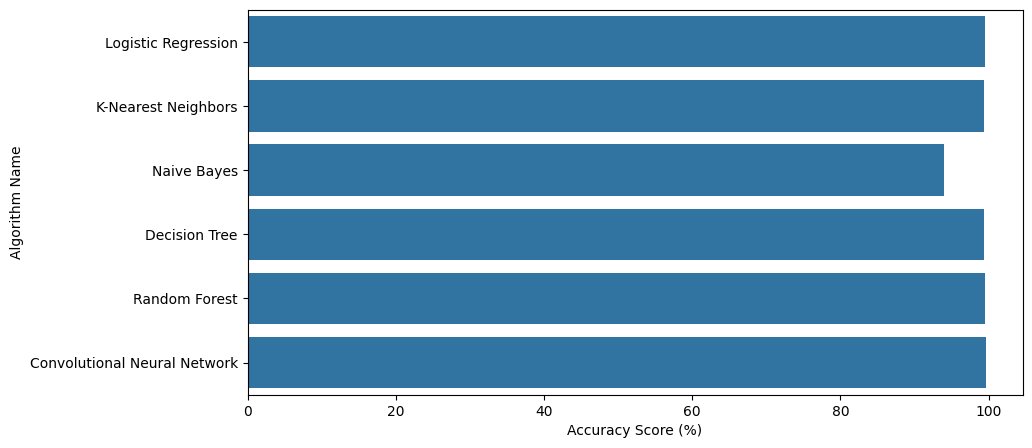

In [54]:
fig = plt.subplots(figsize = (10, 5))
ax = sns.barplot(x = "Accuracy Score (%)", y = "Algorithm Name", data = df)

In [16]:
import os

In [17]:
model_path = "../model/project_model1.h5"
if not os.path.exists(model_path):
    CNN_model.save(model_path)
    print("Model saved successfully")
else:
    print("Model already exists. Skipping save.")

NameError: name 'CNN_model' is not defined